## importing required stuff
#### The model was designed using tensorflow keras
Importing the required libraries we are only importing tensorflow and matplotlib

# Train

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

## Loading dataset

Below we are rescalling right at the begining by using the image data generator at the keras processing images

In [4]:
# Data loading
trainingData = ImageDataGenerator(rescale=1./255)
validatingData = ImageDataGenerator(rescale=1./255)

trainingImages = trainingData.flow_from_directory(
    './train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

validationImages = validatingData.flow_from_directory(
    './valid',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

Found 7213 images belonging to 11 classes.
Found 1543 images belonging to 11 classes.


### So in the above we are importing images with a 244 / 244 size and in a single batch we are having 32 images for faster training times.

## Model building

In [5]:
# Model definition
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(len(trainingImages.class_indices), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Model Training

In [6]:
# Training

history = model.fit(
    trainingImages,
    epochs=10,
    validation_data=validationImages
)

Epoch 1/10
226/226 [==============================] - 47s 176ms/step - loss: 2.3620 - accuracy: 0.1662 - val_loss: 2.2932 - val_accuracy: 0.1607
Epoch 2/10
226/226 [==============================] - 38s 166ms/step - loss: 2.1654 - accuracy: 0.2159 - val_loss: 2.1259 - val_accuracy: 0.2456
Epoch 3/10
226/226 [==============================] - 38s 169ms/step - loss: 2.0285 - accuracy: 0.2745 - val_loss: 2.0557 - val_accuracy: 0.2644
Epoch 4/10
226/226 [==============================] - 38s 167ms/step - loss: 1.8079 - accuracy: 0.3600 - val_loss: 2.1220 - val_accuracy: 0.2592
Epoch 5/10
226/226 [==============================] - 37s 165ms/step - loss: 1.4846 - accuracy: 0.4863 - val_loss: 2.1733 - val_accuracy: 0.2890
Epoch 6/10
226/226 [==============================] - 38s 167ms/step - loss: 1.0339 - accuracy: 0.6504 - val_loss: 2.5030 - val_accuracy: 0.2975
Epoch 7/10
226/226 [==============================] - 39s 173ms/step - loss: 0.6811 - accuracy: 0.7767 - val_loss: 2.8793 - val_ac

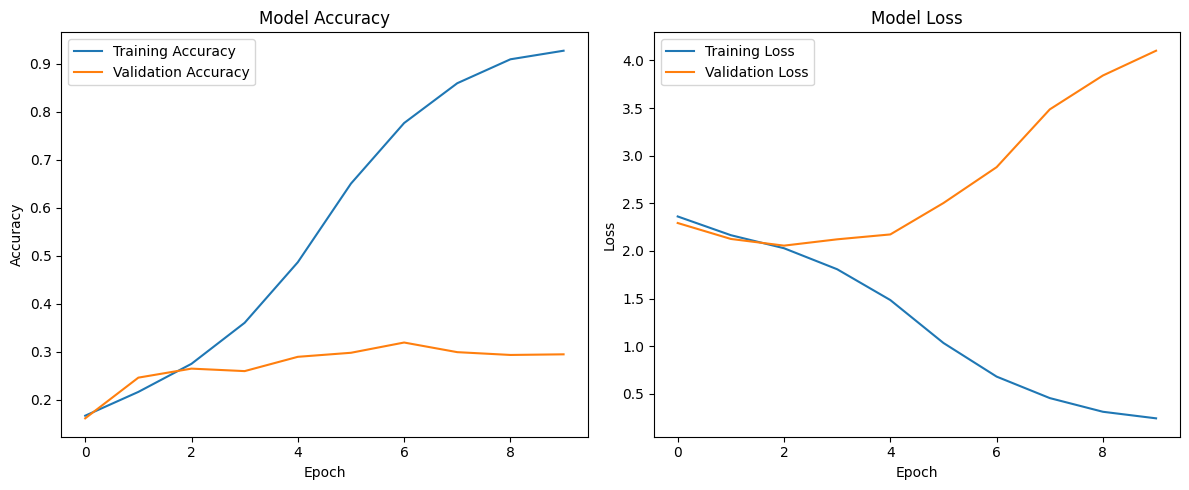

In [7]:
# Plot training and validation accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Test

In [8]:
# Prepare test data
testData = ImageDataGenerator(rescale=1./255)

testingImages = testData.flow_from_directory(
    './valid',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)

# Evaluate model
loss, accuracy = model.evaluate(testingImages)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}')

Found 1543 images belonging to 11 classes.
49/49 [==============================] - 7s 137ms/step - loss: 4.1016 - accuracy: 0.2942
Test Loss: 4.1016, Test Accuracy: 0.2942


Exporting model

In [13]:
model.save("model.h5")